In [1]:
import numpy as np 
import healpy as hp
import pandas as pd
import matplotlib.pyplot as plt
import tifffile as tiff
import glob
import seaborn as sns
# sns.set_style("darkgrid")
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from num2words import num2words
from scipy.optimize import curve_fit
from mpl_toolkits import mplot3d
import os
from distfit import distfit
import sys
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
%matplotlib inline
# %matplotlib notebook

## Read Country DB parameters

In [2]:
csv_files = ['./database/Russia.csv']


#France has 9393 Tx
#DB has 


# --Create an empty dataframe to store the combined data-- #
df = pd.DataFrame()

# Loop through each CSV file and append its contents to the combined dataframe
for csv_file in (csv_files):
    df_temp = pd.read_csv(csv_file)
    df = pd.concat([df, df_temp],ignore_index=True)

df=df.dropna()
power=df['EIRP'].to_numpy()
lat_128=df['Latitude in degrees'].to_numpy()
lon_128=df['Longitude in degrees'].to_numpy()

pix=hp.ang2pix(128,lon_128,lat_128,lonlat=True)

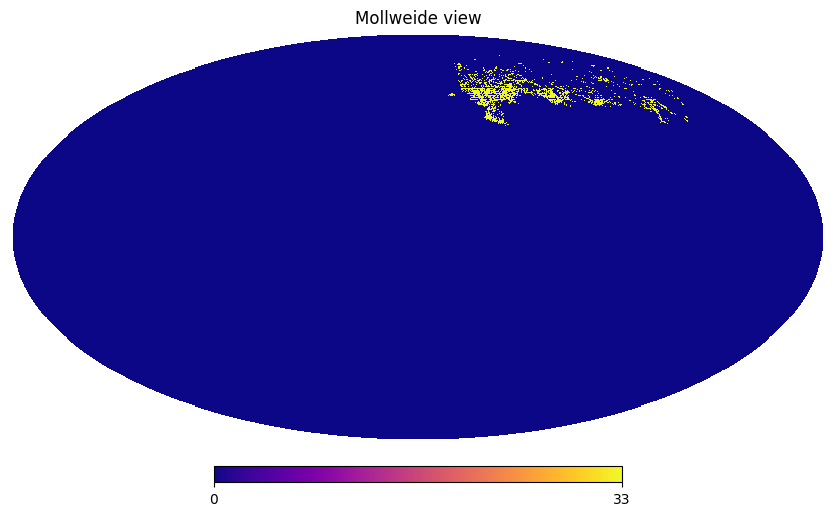

In [3]:

Tx_num_128=np.zeros(hp.nside2npix(128))
for pi in pix:
    Tx_num_128[pi]+=1
hp.mollview(Tx_num_128,flip='geo',cmap='plasma',norm='hist')
plt.show()

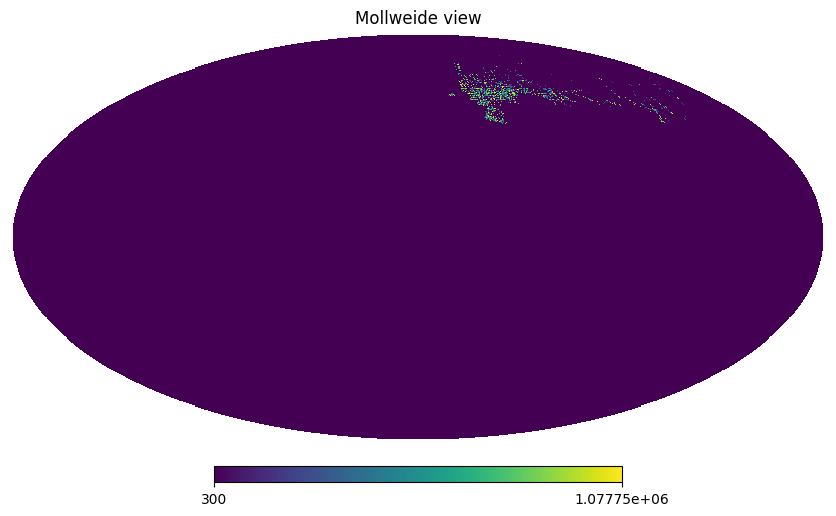

In [4]:
Tx_pow_128=np.zeros(hp.nside2npix(128))
for index,p in enumerate(pix):
    Tx_pow_128[p]+=(power[index])
hp.mollview(Tx_pow_128,flip='geo',cmap='viridis',norm='hist',min=300)
plt.show()

## Fitting PDF to Tx params

In [5]:
fr_df=pd.read_csv('./database/Russia.csv')
fr_df=fr_df.dropna()
lat=fr_df['Latitude in degrees'].to_numpy()
lon=fr_df['Longitude in degrees'].to_numpy()
power=fr_df['EIRP'].to_numpy()
freq=fr_df['Frequency(MHz)'].to_numpy()

In [6]:
#bin width using Freedman Diaconis rule#
def FDrule(inarg):
    qr1,qr2=np.percentile(inarg,[25,75])
    iqr=qr2-qr1
    width=(2*iqr)/(np.size(iqr)**(1/3))
    return int(width)

## Model Latitude

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [alpha          ] [0.07 sec] [RSS: 0.00196453] [loc=-83.465 scale=3477.132]
[distfit] >INFO> [anglit         ] [0.01 sec] [RSS: 0.00505132] [loc=56.488 scale=21.417]
[distfit] >INFO> [arcsine        ] [0.04 sec] [RSS: 0.0137503] [loc=41.569 scale=31.733]
[distfit] >INFO> [beta           ] [0.11 sec] [RSS: 0.00148388] [loc=-2770.948 scale=3117.567]
[distfit] >INFO> [betaprime      ] [0.12 sec] [RSS: 0.00165689] [loc=-153.409 scale=6.322]
[distfit] >INFO> [bradford       ] [0.03 sec] [RSS: 0.00879008] [loc=41.570 scale=31.733]
[distfit] >INFO> [burr           ] [0.37 sec] [RSS: 0.000718842] [loc=-0.332 scale=56.882]
[distfit] >INFO> [cauchy         ] [0.00 sec] [RSS: 0.00143898] [loc=54.764 scale=2.718]
[distfit] >INFO> [chi            ] [0.07 sec] [RSS: 0.00165926] [loc=-19.148 scale=7.664]
[distfit] >INFO> [chi2           ] [0.07 sec] [RSS: 0.00188781] [loc=0.093 scale=0.277]
[distfit] >INFO> [cosine         ] [0.03 sec] 

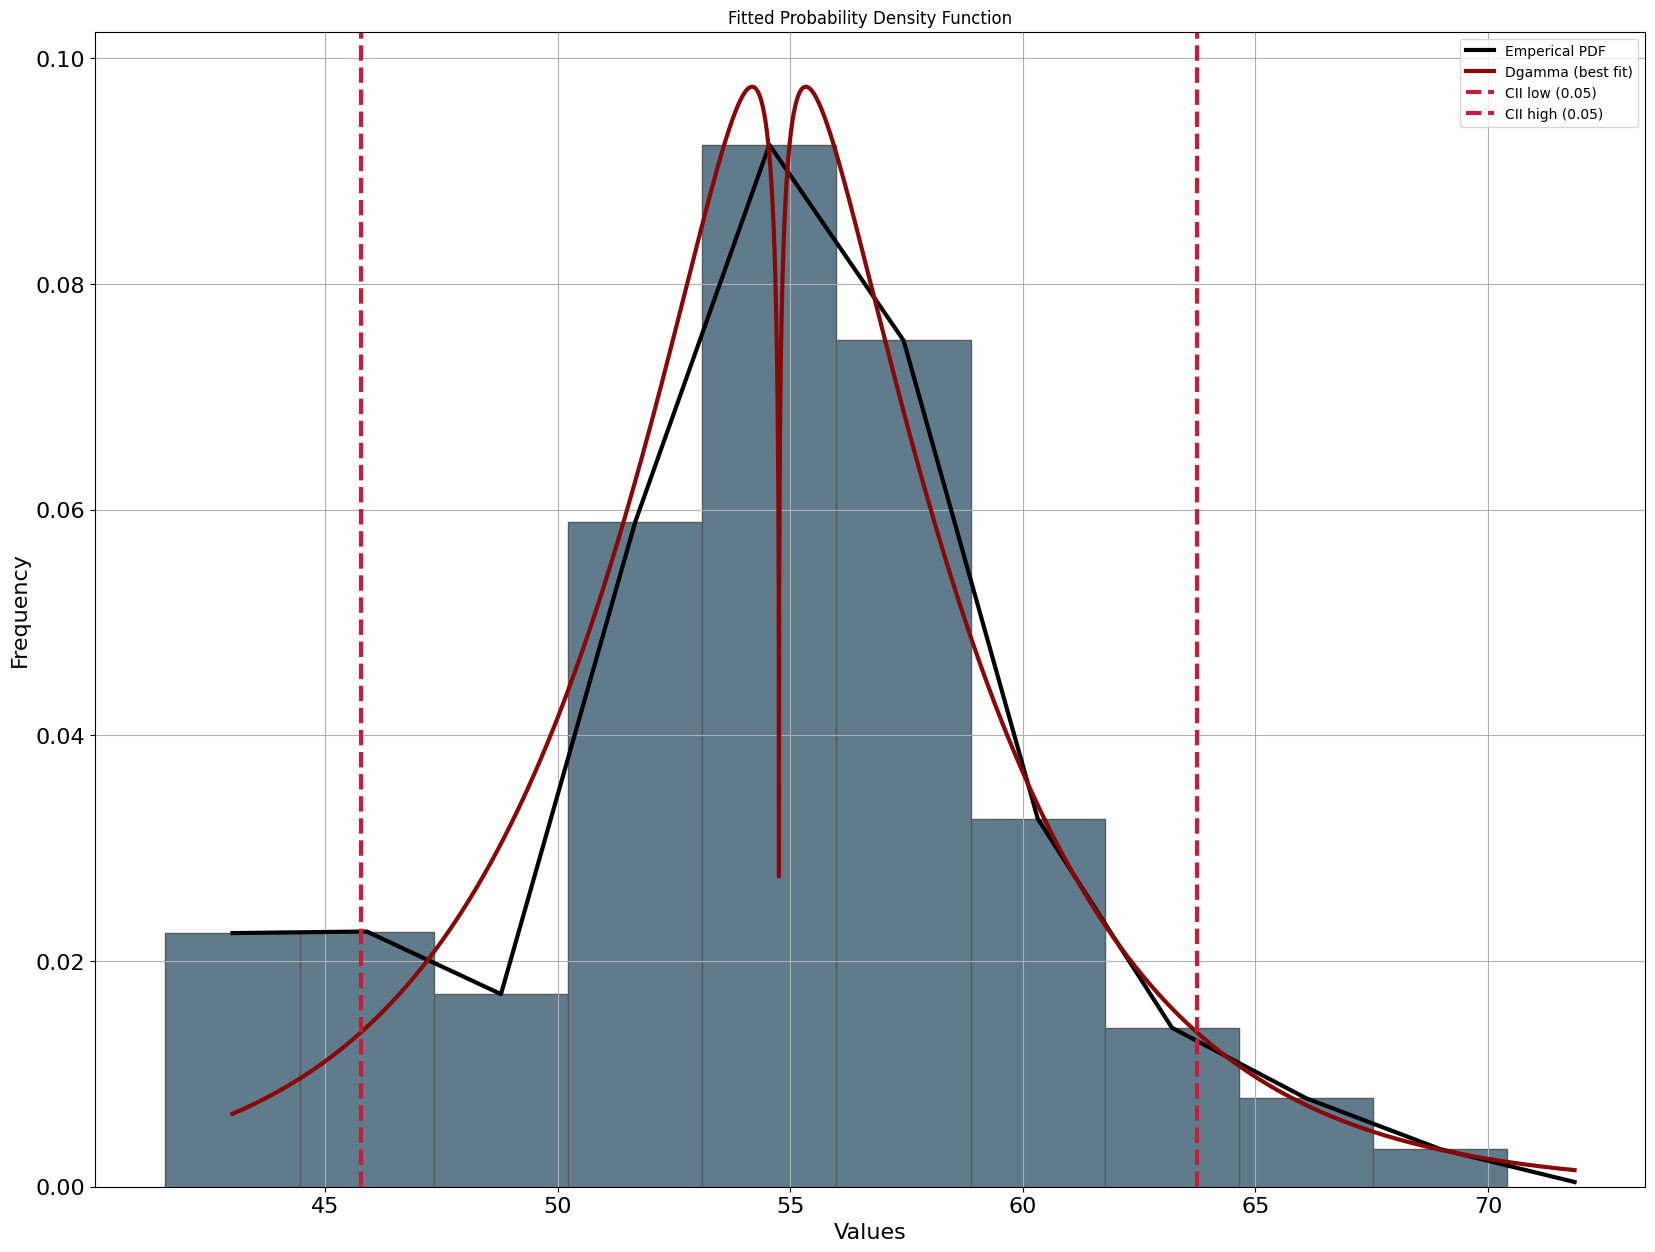

Best fitted distribution: dgamma
Parameters: (1.1662224892083912, 54.757142361910454, 3.474293790410162)


In [7]:
binw=FDrule(lat)
# Fit a probability density function
distlat = distfit(distr='full',bins=binw)
distlat.fit_transform(lat)

# Plot the fitted distribution
distlat.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distlat.model['name'])
print("Parameters:", distlat.model['params'])


## Model longitude

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [alpha          ] [0.06 sec] [RSS: 0.00171064] [loc=-16.994 scale=227.205]
[distfit] >INFO> [anglit         ] [0.02 sec] [RSS: 0.00430978] [loc=80.284 scale=109.466]
[distfit] >INFO> [arcsine        ] [0.04 sec] [RSS: 0.00626172] [loc=19.550 scale=151.512]
[distfit] >INFO> [beta           ] [0.12 sec] [RSS: 0.0019945] [loc=19.350 scale=20536392.157]
[distfit] >INFO> [betaprime      ] [0.10 sec] [RSS: 0.00182777] [loc=-0.776 scale=1.555]
[distfit] >INFO> [bradford       ] [0.07 sec] [RSS: 0.00385155] [loc=19.550 scale=148.286]
[distfit] >INFO> [burr           ] [0.35 sec] [RSS: 0.00150776] [loc=-0.098 scale=21.600]
[distfit] >INFO> [cauchy         ] [0.00 sec] [RSS: 0.00265581] [loc=50.814 scale=15.355]
[distfit] >INFO> [chi            ] [0.06 sec] [RSS: 0.0129696] [loc=19.550 scale=5.380]
[distfit] >INFO> [chi2           ] [0.04 sec] [RSS: 0.0019895] [loc=19.235 scale=10.109]
[distfit] >INFO> [cosine         ] [0.03 sec] 

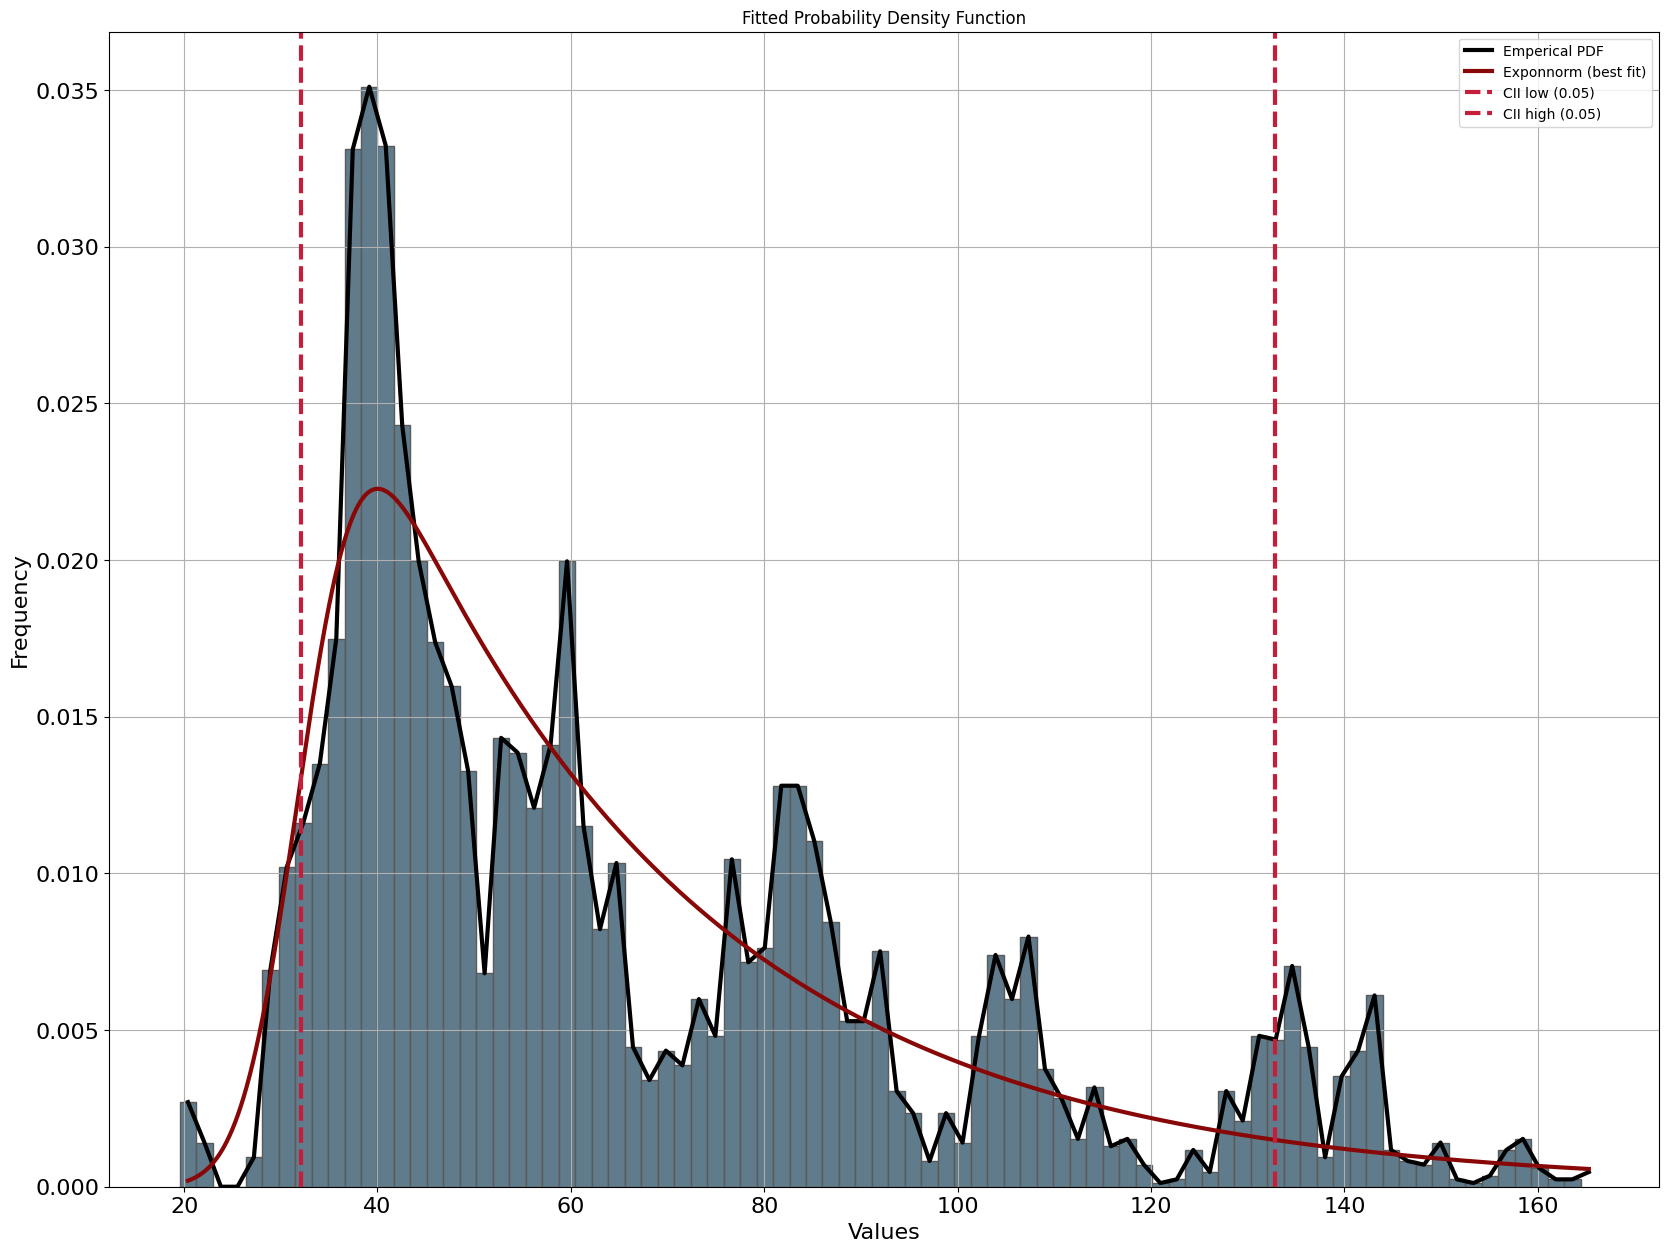

Best fitted distribution: exponnorm
Parameters: (6.981475832217603, 32.23825114230188, 4.791216709090322)


In [8]:
binwi=FDrule(lon)
# Fit a probability density function
distlon = distfit(distr='full',bins=binwi)
distlon.fit_transform(lon)

# Plot the fitted distribution
distlon.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distlon.model['name'])
print("Parameters:", distlon.model['params'])


## Generate lon lat vals

In [9]:
newlat=distlat.generate(30000)


In [10]:
newlon=distlon.generate(30000)

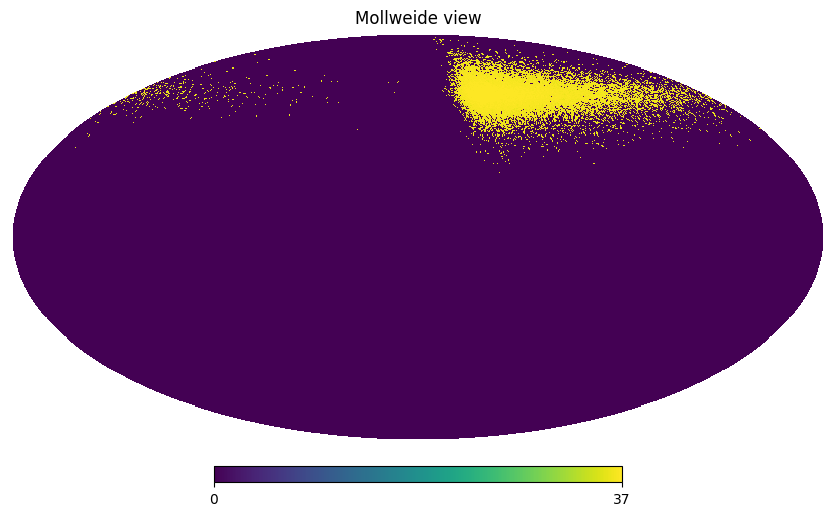

In [11]:
newfrpix=hp.ang2pix(128,newlon,newlat,lonlat=True)
newmap=np.zeros(hp.nside2npix(128))
for pp in newfrpix:
    newmap[pp]+=1
hp.mollview(newmap,flip='geo',norm='hist')

In [12]:
valpix=np.argwhere(Tx_num_128)
diff=Tx_num_128[valpix]-newmap[valpix]

## Model Tx power

[distfit] >INFO> fit
[distfit] >INFO> transform
[distfit] >INFO> [powerlaw] [0.06 sec] [RSS: 0.000149658] [loc=-0.000 scale=160000.000]


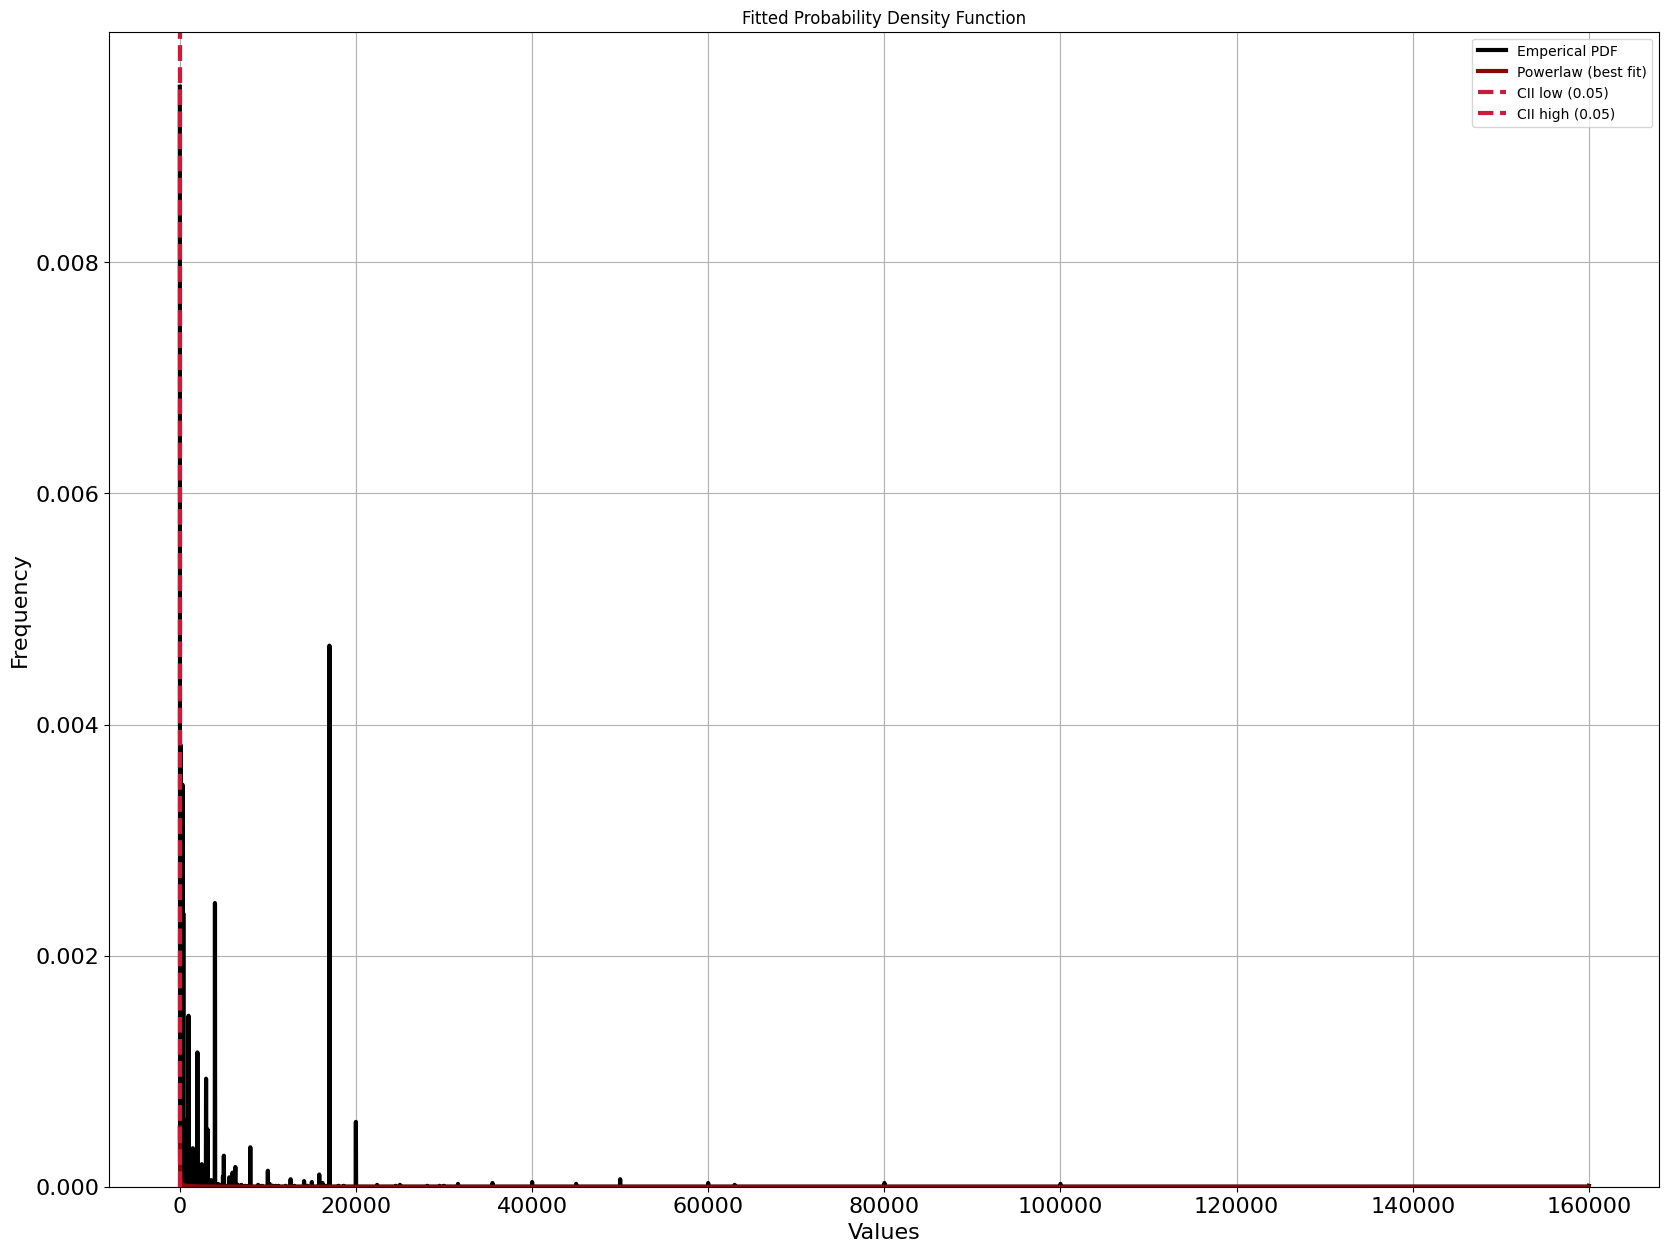

Best fitted distribution: powerlaw
Parameters: (0.006728533047148055, -2.2250738585072014e-308, 160000.00000000003)


In [13]:
powbin=FDrule(power)
# Fit a probability density function
distpow = distfit(distr='powerlaw',bins=powbin)
distpow.fit_transform(power)

# Plot the fitted distribution
distpow.plot()
plt.title('Fitted Probability Density Function')
plt.show()

# Get information about the best-fitted distribution
print("Best fitted distribution:", distpow.model['name'])
print("Parameters:", distpow.model['params'])


In [14]:
newpow=distpow.generate(30000)

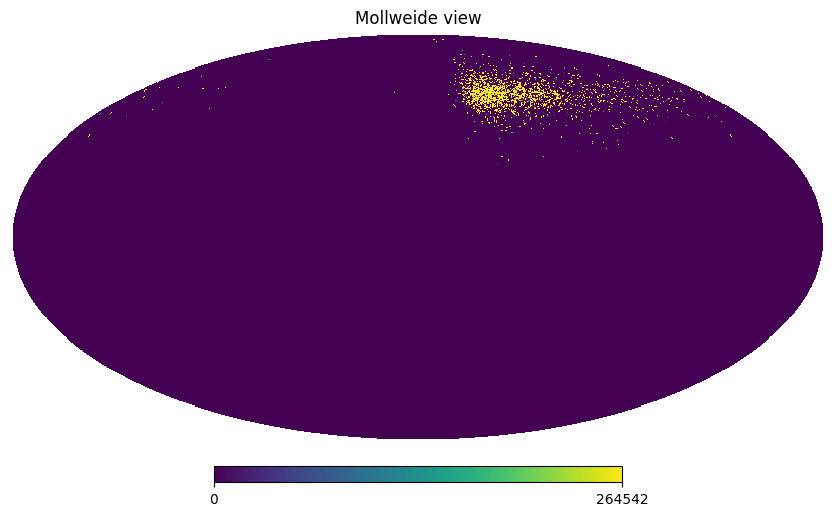

In [15]:
new_powmap=np.zeros(hp.nside2npix(128))
for index,p in enumerate(newfrpix):
    new_powmap[p]+=(newpow[index])
hp.mollview(new_powmap,flip='geo',cmap='viridis',norm='hist',min=0)
plt.show()

## Border data as  limits for generated data

In [16]:
border_data=pd.read_json('./russia_lon_lat_arrays.json')

In [17]:
ruslon=border_data['longitude'].to_numpy()
ruslat=border_data['latitude'].to_numpy()


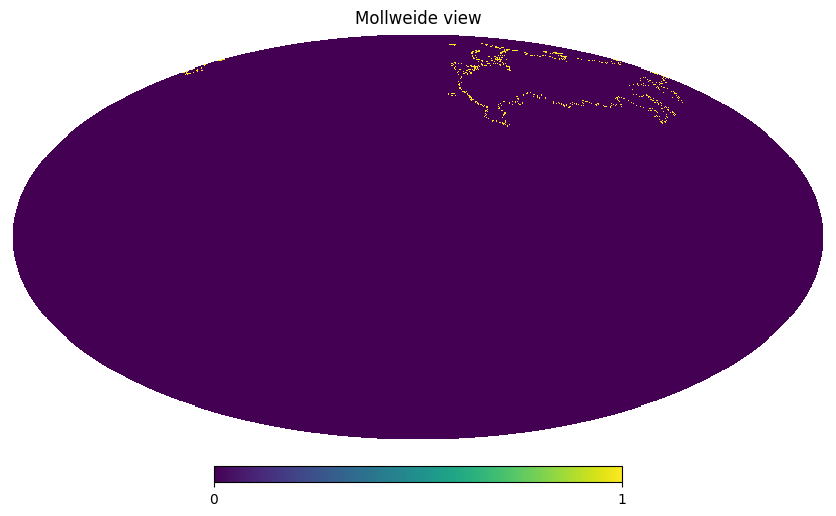

In [18]:
rusborder=np.zeros(hp.nside2npix(128))
rusborpix=hp.ang2pix(128,ruslon,ruslat,lonlat=True)
for pixe in rusborpix:
    rusborder[pixe]+=1
rusborder=np.where(rusborder != 0, 1, 0)
hp.mollview(rusborder,flip='geo',norm='hist')

## filter out bad pixels from generated data

## Tx number per pixel residuals

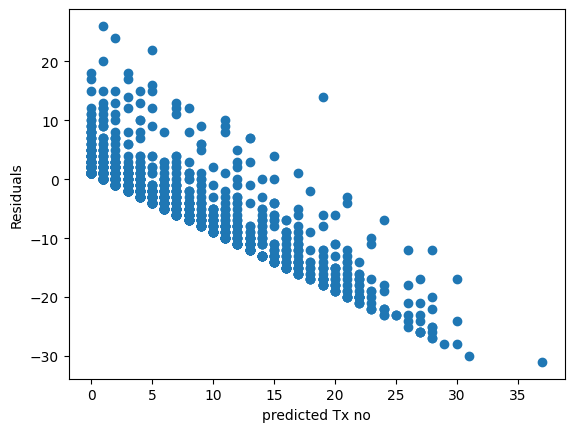

In [19]:
plt.scatter(newmap[valpix],diff)
plt.xlabel('predicted Tx no')
plt.ylabel('Residuals')
plt.show()

In [20]:
power_res=Tx_pow_128[valpix]-new_powmap[valpix]

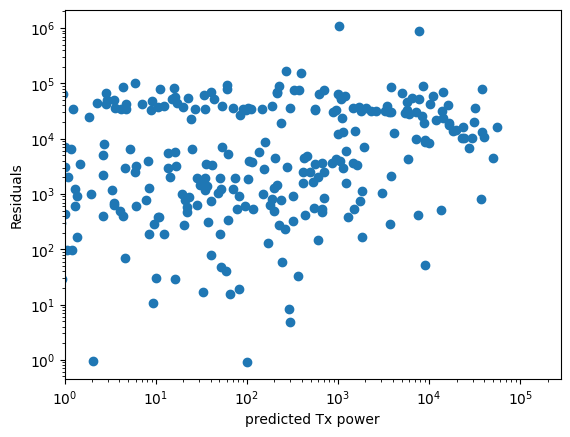

In [42]:
plt.scatter(new_powmap[valpix],power_res)
plt.xlabel('predicted Tx power')
plt.ylabel('Residuals')
plt.xlim(left=1e0)
plt.xscale('log')
plt.yscale('log')
plt.show()